# Comparación de Modelos de Predicción BIS

**Modelos comparados:**
- `ModeloLSTMBIS` — LSTM simple con pérdida SLD
- `ModeloAnestesia` — CNN + LSTM + Atención multicabeza
- `ModeloEcDif` — Modelo PK-PD de ecuaciones diferenciales (Ionescu *et al.*, IEEE Access 2021)

El modelo de ecuaciones diferenciales usa la farmacocinética de 3 compartimentos
+ sitio de efecto para **Propofol** (Schnider) y **Remifentanilo** (Minto), y la
superficie de interacción tipo Hill para predecir BIS. Los parámetros PD
(C50 y γ del Propofol) se obtienen por **ajuste lineal multivariable** sobre la
Tabla 1 del artículo, en función de Edad / Altura / Peso del paciente.


In [1]:

import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

# Dirección para Modelo_Predictor_BIS.py
ESCRITORIO = r"C:\Users\yordi\Desktop"
if ESCRITORIO not in sys.path:
    sys.path.insert(0, ESCRITORIO)

from Modelo_Predictor_BIS import ModeloAnestesia

# =============================================================================
# CLASE LSTMBIS — definida aquí directamente
# =============================================================================
# El archivo modelo_lstm_bis_sld.pt fue entrenado con DOS LSTMs separadas
# (lstm_propofol + lstm_remifentanilo) y regresor 128->64->1.
# Esa es la arquitectura del notebook de entrenamiento (clase LSTMBIS),
# distinta de ModeloLSTMBIS del .py (una sola LSTM, regresor 64->32->1).
# =============================================================================
class LSTMBIS(nn.Module):
    def __init__(self, unidades_lstm=64, num_capas=2, dropout=0.25):
        super().__init__()
        lstm_kwargs = dict(
            hidden_size=unidades_lstm, num_layers=num_capas,
            batch_first=True,
            dropout=dropout if num_capas > 1 else 0.0
        )
        self.lstm_propofol      = nn.LSTM(input_size=1, **lstm_kwargs)
        self.lstm_remifentanilo = nn.LSTM(input_size=1, **lstm_kwargs)
        self.regresor = nn.Sequential(
            nn.Linear(unidades_lstm * 2, unidades_lstm),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(unidades_lstm, 1)
        )

    def forward(self, x):
        _, (h_p, _) = self.lstm_propofol(x[:, :, 0:1])
        _, (h_r, _) = self.lstm_remifentanilo(x[:, :, 1:2])
        h = torch.cat([h_p[-1], h_r[-1]], dim=1)
        return self.regresor(h).squeeze(-1)


print("Clases listas.")


Clases listas.


In [2]:
# =============================================================================
# CONFIGURACIÓN
# =============================================================================

# ── Rutas de los modelos  ───────────────────────────────────────────
RUTA_LSTM      = r"C:\Users\yordi\Desktop\modelo_lstm_bis_sld.pt"
RUTA_ANESTESIA = r"C:\Users\yordi\Desktop\modeloBIS.pt"

# ── Carpeta con los CSV (se usan para la tabla de métricas) ─────────────
CARPETA_CSV    = r"C:\Users\yordi\Desktop\Prueba_Limpios"

# ── Archivo  para la GRÁFICA comparativa ───────────────────────────
RUTA_CSV_GRAFICA = r"C:\Users\yordi\Desktop\Prueba_Limpios\Paciente_5278_limpio_SinFiltro.csv"

# ── Nombres de columnas en los CSV ───────────────────────────────────────────
COL_PPF   = "PPF20_RATE"    # tasa de infusión de Propofol
COL_RFTN  = "RFTN20_RATE"   # tasa de infusión de Remifentanilo
COL_BIS   = "BIS"           # BIS real
COL_T     = "t"             # tiempo 

# Covariables NORMALIZADAS 
COLS_COV_NORM = ["Edad_Norm", "Peso_norm", "Altura_norm", "Sexo_norm"]

# Covariables (las usa el modelo de ecuaciones diferenciales)
COL_EDAD   = "Edad"     # años
COL_PESO   = "Peso"     # kg
COL_ALTURA = "Altura"   # cm
COL_SEXO   = "Sexo"     # "M" = hombre, "F" = mujer

# ── Ganancia de infusión: masa/min por cada unidad de la columna RATE ─────────
# El modelo PK-PD necesita la entrada en mg/min (Propofol) y µg/min (Remi).
# Las tasas de los CSV están en mL/s. El vial es PPF20 = 20 mg/mL y
# RFTN20 = 20 µg/mL, así que para pasar a masa por minuto:
#       u_propofol     [mg/min]  = RATE[mL/s] * 20[mg/mL] * 60[s/min]
#       u_remifentanilo[µg/min]  = RATE[mL/s] * 20[µg/mL] * 60[s/min]
#


GANANCIA_PPF  = 20.0 * 60.0   # mg/min por unidad de PPF20_RATE  (mL/s)
GANANCIA_RFTN = 20.0 * 60.0   # µg/min por unidad de RFTN20_RATE (mL/s)
FACTOR_T_A_MIN  = 1.0/60.0   # segundos -> minutos

# ── Parámetros PD del modelo de ecuaciones diferenciales ─────────────────────
C50_REMI = 11.4    # ng/mL  Remifentanilo->BIS
GAMMA_REMI = 2.5   
SIGMA_SINERGIA = 0.2   # término de sinergia σ de la superficie de Hill.
E0_BIS   = 97.7    # BIS basal (paciente despierto, sin fármaco)
EMAX_BIS = 97.7    # efecto máximo (caída de BIS); E0=EMAX -> BIS = E0/(1+I^γ)

# ── Hiperparámetros ────────────────────────────────────────────────────────────────────
VENTANA   = 180    # tamaño de ventana de las redes neuronales
EPS_NORM  = 1e-8   # epsilon para evitar división por cero en la normalización
EPS_MAPE  = 1e-6   # umbral para descartar BIS ~ 0 en el MAPE
DT_MAX_MIN = 1.0/60.0  # sub-paso máximo de integración del ODE (1 s)

dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {dispositivo}")


Dispositivo: cuda


In [3]:
# =============================================================================
# CARGA DE MODELOS 
# =============================================================================

# ── LSTMBIS  ──────────────────────────────────────
modelo_lstm = LSTMBIS().to(dispositivo)
modelo_lstm.load_state_dict(
    torch.load(RUTA_LSTM, map_location=dispositivo, weights_only=True)
)
modelo_lstm.eval()
print("LSTMBIS cargado.")

# ── ModeloAnestesia ──────────────────────────────────────────────────────────
modelo_anestesia = ModeloAnestesia().to(dispositivo)
modelo_anestesia.load_state_dict(
    torch.load(RUTA_ANESTESIA, map_location=dispositivo, weights_only=True)
)
modelo_anestesia.eval()
print("ModeloAnestesia cargado.")


LSTMBIS cargado.
ModeloAnestesia cargado.


In [4]:
# =============================================================================
# MODELO DE ECUACIONES DIFERENCIALES PK-PD.
# =============================================================================
# Estructura:
#   1) PK de 3 compartimentos + sitio de efecto para Propofol 
#      y Remifentanilo, integrada con la entrada de infusión.
#   2) Superficie de interacción tipo Hill -> BIS.
#   3) Parámetros PD (C50_prop, γ_prop) por AJUSTE LINEAL MULTIVARIABLE sobre
#      la Tabla 1, en función de (Edad, Altura, Peso).
# =============================================================================

# ── Tabla 1 del artículo: [Edad(años), Altura(cm), Peso(kg), C50, gamma] ──────
TABLA1 = np.array([
    [74, 164,  88, 2.5 , 3.00],
    [67, 161,  69, 4.6 , 2.00],
    [75, 176, 101, 5.0 , 1.60],
    [69, 173,  97, 1.8 , 2.50],
    [45, 171,  64, 6.8 , 1.78],
    [57, 182,  80, 2.7 , 2.80],
    [74, 155,  55, 1.7 , 3.50],
    [71, 172,  78, 7.8 , 2.90],
    [65, 176,  77, 2.9 , 1.88],
    [72, 192,  73, 3.9 , 3.10],
    [69, 168,  84, 2.3 , 3.10],
    [60, 190,  92, 4.8 , 2.10],
    [61, 177,  81, 2.5 , 3.00],
    [54, 173,  86, 2.5 , 3.00],
    [71, 172,  83, 4.3 , 1.90],
    [53, 186, 114, 2.7 , 1.60],
    [72, 162,  87, 4.5 , 2.90],
    [61, 182,  93, 2.7 , 1.78],
    [70, 167,  77, 6.8 , 3.10],
    [69, 168,  82, 9.8 , 1.60],
    [69, 158,  81, 3.2 , 2.10],
    [60, 165,  85, 5.1 , 2.51],
    [70, 173,  69, 3.67, 3.10],
    [56, 186,  99, 5.8 , 2.30],
], dtype=np.float64)

# Ajuste lineal multivariable:  param = b0 + b1*Edad + b2*Altura + b3*Peso
#   (mínimos cuadrados; np.linalg.lstsq)
_X_fit = np.column_stack([np.ones(len(TABLA1)), TABLA1[:, 0], TABLA1[:, 1], TABLA1[:, 2]])
_coef_C50, *_   = np.linalg.lstsq(_X_fit, TABLA1[:, 3], rcond=None)
_coef_GAMMA, *_ = np.linalg.lstsq(_X_fit, TABLA1[:, 4], rcond=None)

# Rangos observados (para acotar extrapolaciones a valores físicos)
_C50_MIN,   _C50_MAX   = TABLA1[:, 3].min(), TABLA1[:, 3].max()
_GAMMA_MIN, _GAMMA_MAX = TABLA1[:, 4].min(), TABLA1[:, 4].max()

def interpolar_pd(edad, altura, peso):
    """Devuelve (C50_prop [µg/mL], gamma_prop [-]) por ajuste lineal de la Tabla 1."""
    v = np.array([1.0, edad, altura, peso])
    c50   = float(np.clip(v @ _coef_C50,   _C50_MIN,   _C50_MAX))
    gamma = float(np.clip(v @ _coef_GAMMA, _GAMMA_MIN, _GAMMA_MAX))
    return c50, gamma

print("Ajuste C50  = %.4f + %.4f*Edad + %.4f*Altura + %.4f*Peso"
      % tuple(_coef_C50))
print("Ajuste gamma= %.4f + %.4f*Edad + %.4f*Altura + %.4f*Peso"
      % tuple(_coef_GAMMA))


# ── Masa magra (LBM), Ec. 4 (hombre) y Ec. 5 (mujer) ─────────────────────────
def calcular_lbm(peso, altura, sexo):
    """peso[kg], altura[cm], sexo 'M'/'F'."""
    es_hombre = str(sexo).strip().upper().startswith("M")
    if es_hombre:
        return 1.10 * peso - 128.0 * (peso / altura) ** 2
    else:
        return 1.07 * peso - 148.0 * (peso / altura) ** 2


# ── Parámetros PK ────────────────────────────────────────────────────────────
def parametros_propofol(edad, peso, altura, lbm):
    """Schnider (Ec. 8). Devuelve dict con k's, V1, ke0, k1e."""
    V1 = 4.27
    V3 = 238.0
    V2 = 18.9 - 0.391 * (edad - 53)
    Cl1 = 1.89 + 0.0456 * (peso - 77) - 0.0681 * (lbm - 59) + 0.0264 * (altura - 177)
    Cl2 = 1.29 - 0.024 * (edad - 53)
    Cl3 = 0.836
    return dict(
        V1=V1,
        k10=Cl1 / V1, k12=Cl2 / V1, k13=Cl3 / V1,
        k21=Cl2 / V2, k31=Cl3 / V3,
        ke0=0.456, k1e=0.456,
    )

def parametros_remifentanilo(edad, lbm):
    """Minto (Ec. 9). Devuelve dict con k's, V1, ke0, k1e."""
    V1 = 5.1 - 0.0201 * (edad - 40) + 0.072 * (lbm - 55)
    V2 = 9.82 - 0.0811 * (edad - 40) + 0.108 * (lbm - 55)
    V3 = 5.42
    Cl1 = 2.6 + 0.0162 * (edad - 40) + 0.0191 * (lbm - 55)
    Cl2 = 2.05 - 0.0301 * (edad - 40)
    Cl3 = 0.076 - 0.00113 * (edad - 40)
    ke0 = 0.595 - 0.007 * (edad - 40)
    return dict(
        V1=V1,
        k10=Cl1 / V1, k12=Cl2 / V1, k13=Cl3 / V1,
        k21=Cl2 / V2, k31=Cl3 / V3,
        ke0=ke0, k1e=ke0,   # k1e = ke0 (compartimento de efecto estándar)
    )


# ── Integrador del PK (Ec. 1-3): devuelve la concentración de efecto xe(t) ────
def integrar_efecto(u, dt_min, p, dt_max=DT_MAX_MIN):
    """
    u      : array (N,) tasa de infusión en masa/min (mg/min o µg/min)
    dt_min : array (N,) paso de tiempo en minutos para avanzar en cada muestra
    p      : dict de parámetros PK (de las funciones de arriba)
    Devuelve xe : array (N,) concentración en el sitio de efecto.
    Integración Euler explícita.
    """
    N = len(u)
    x1 = x2 = x3 = xe = 0.0
    a = p["k10"] + p["k12"] + p["k13"]
    k12, k13, k21, k31 = p["k12"], p["k13"], p["k21"], p["k31"]
    ke0, k1e, V1 = p["ke0"], p["k1e"], p["V1"]
    ce = np.empty(N, dtype=np.float64)
    for i in range(N):
        ce[i] = xe                      # estado actual = BIS de la muestra i
        nsub = max(1, int(np.ceil(dt_min[i] / dt_max)))
        h = dt_min[i] / nsub
        ui_V1 = u[i] / V1
        for _ in range(nsub):
            dx1 = -a * x1 + k21 * x2 + k31 * x3 + ui_V1
            dx2 = k12 * x1 - k21 * x2
            dx3 = k13 * x1 - k31 * x3
            dxe = k1e * x1 - ke0 * xe
            x1 += h * dx1; x2 += h * dx2; x3 += h * dx3; xe += h * dxe
    return ce


# ── Predicción de BIS con el modelo de ecuaciones diferenciales ──────────────
def predecir_bis_ecdif(rate_ppf, rate_rftn, dt_min, edad, peso, altura, sexo):
    """Devuelve array (N,) con el BIS predicho por el modelo PK-PD."""
    lbm = calcular_lbm(peso, altura, sexo)

    # Tasa de infusión -> masa/min (ver GANANCIA_* en la CELDA 2)
    u_prop = rate_ppf  * GANANCIA_PPF    # mg/min
    u_remi = rate_rftn * GANANCIA_RFTN   # µg/min

    p_prop = parametros_propofol(edad, peso, altura, lbm)
    p_remi = parametros_remifentanilo(edad, lbm)

    ce_prop = integrar_efecto(u_prop.astype(np.float64), dt_min, p_prop)  # µg/mL
    ce_remi = integrar_efecto(u_remi.astype(np.float64), dt_min, p_remi)  # ng/mL

    c50_prop, gamma_prop = interpolar_pd(edad, altura, peso)

    # Superficie de interacción de Hill 
    Up = ce_prop / c50_prop
    Ur = ce_remi / C50_REMI
    I = Up + Ur + SIGMA_SINERGIA * Up * Ur
    efecto = EMAX_BIS * (I ** gamma_prop) / (1.0 + I ** gamma_prop)
    bis = E0_BIS - efecto
    return bis.astype(np.float32)

print("Modelo de ecuaciones diferenciales listo.")


Ajuste C50  = 5.9260 + -0.0093*Edad + 0.0017*Altura + -0.0173*Peso
Ajuste gamma= 2.0138 + 0.0205*Edad + 0.0043*Altura + -0.0196*Peso
Modelo de ecuaciones diferenciales listo.


In [5]:
# =============================================================================
# FUNCIÓN DE NORMALIZACIÓN POR VENTANA
# =============================================================================

def normalizar_ventana(arr: np.ndarray) -> np.ndarray:
    """
    Normaliza un array 1-D o 2-D restando la media y dividiendo
    entre la desviación estándar de la ventana + EPS_NORM.

    Si arr tiene forma (T,)  -> normaliza todo el vector.
    Si arr tiene forma (T,C) -> normaliza canal a canal.
    """
    if arr.ndim == 1:
        media = arr.mean()
        std   = arr.std() + EPS_NORM
        return (arr - media) / std
    else:
        media = arr.mean(axis=0, keepdims=True)
        std   = arr.std(axis=0,  keepdims=True) + EPS_NORM
        return (arr - media) / std


In [6]:
# ============================================================================
# Redes neuronales (LSTM y ModeloAnestesia): ventana deslizante de VENTANA
# puntos con relleno de ceros a la izquierda.
# Modelo de ecuaciones diferenciales: integración del PK-PD sobre toda la señal.
# =============================================================================

def _ventana_2d(arr2d, idx, vent):
    inicio = idx - vent
    if inicio >= 0:
        return arr2d[inicio:idx].copy()
    bloque = arr2d[0:idx].copy()
    pad    = np.zeros((-inicio, arr2d.shape[1]), dtype=np.float32)
    return np.vstack([pad, bloque])

def _ventana_1d(arr1d, idx, vent):
    inicio = idx - vent
    if inicio >= 0:
        return arr1d[inicio:idx].copy()
    bloque = arr1d[0:idx].copy()
    pad    = np.zeros(-inicio, dtype=np.float32)
    return np.concatenate([pad, bloque])


def predecir_archivo(ruta_csv):
    """
    Carga un CSV y devuelve un dict con:
      tiempo, bis_gt, pred_lstm, pred_anestesia, pred_ecdif
    """
    df = pd.read_csv(ruta_csv)

    ppf    = df[COL_PPF].values.astype(np.float32)
    rftn   = df[COL_RFTN].values.astype(np.float32)
    bis_gt = df[COL_BIS].values.astype(np.float32)
    N = len(bis_gt)

    tiempo = df[COL_T].values if COL_T in df.columns else np.arange(N)

    # ── Covariables normalizadas para las redes ──────────────────────────────
    cov_np = df[COLS_COV_NORM].values[0].astype(np.float32)
    cov_t  = torch.tensor(cov_np, dtype=torch.float32, device=dispositivo).unsqueeze(0)

    # ── Covariables crudas para el modelo de ecuaciones diferenciales ─────────
    edad   = float(df[COL_EDAD].values[0])
    peso   = float(df[COL_PESO].values[0])
    altura = float(df[COL_ALTURA].values[0])
    sexo   = df[COL_SEXO].values[0]

    # ===== Modelos de redes neuronales (ventana deslizante) =================
    pred_lstm      = np.full(N, np.nan, dtype=np.float32)
    pred_anestesia = np.full(N, np.nan, dtype=np.float32)
    infusiones_np  = np.stack([ppf, rftn], axis=1)   # (N, 2)

    with torch.no_grad():
        for idx in range(N):
            inf_w  = _ventana_2d(infusiones_np, idx, VENTANA)
            inf_wn = normalizar_ventana(inf_w)
            bis_w  = _ventana_1d(bis_gt, idx, VENTANA)
            bis_wn = normalizar_ventana(bis_w)

            # LSTMBIS  -> (1, T, 2)
            x_lstm = torch.tensor(inf_wn, dtype=torch.float32,
                                  device=dispositivo).unsqueeze(0)
            pred_lstm[idx] = modelo_lstm(x_lstm).item()

            # ModeloAnestesia: inf (1,2,T), bis (1,T), cov (1,4)
            inf_t = torch.tensor(inf_wn.T, dtype=torch.float32,
                                 device=dispositivo).unsqueeze(0)
            bis_t = torch.tensor(bis_wn, dtype=torch.float32,
                                 device=dispositivo).unsqueeze(0)
            bis_pred, _ = modelo_anestesia(inf_t, bis_t, cov_t)
            pred_anestesia[idx] = bis_pred.item()

    # ===== Modelo de ecuaciones diferenciales  ========
    # Paso de tiempo en minutos
    if COL_T in df.columns and N > 1:
        dt = np.diff(tiempo).astype(np.float64)
        dt = np.append(dt, dt[-1])
        dt_min = np.abs(dt) * FACTOR_T_A_MIN
    else:
        dt_min = np.full(N, 1.0 * FACTOR_T_A_MIN, dtype=np.float64)  # 1 muestra

    pred_ecdif = predecir_bis_ecdif(ppf, rftn, dt_min, edad, peso, altura, sexo)

    return dict(tiempo=tiempo, bis_gt=bis_gt,
                pred_lstm=pred_lstm,
                pred_anestesia=pred_anestesia,
                pred_ecdif=pred_ecdif,
                nombre=os.path.basename(ruta_csv))

print("Función predecir_archivo() lista.")


Función predecir_archivo() lista.


Graficando: Paciente_5278_limpio_SinFiltro.csv


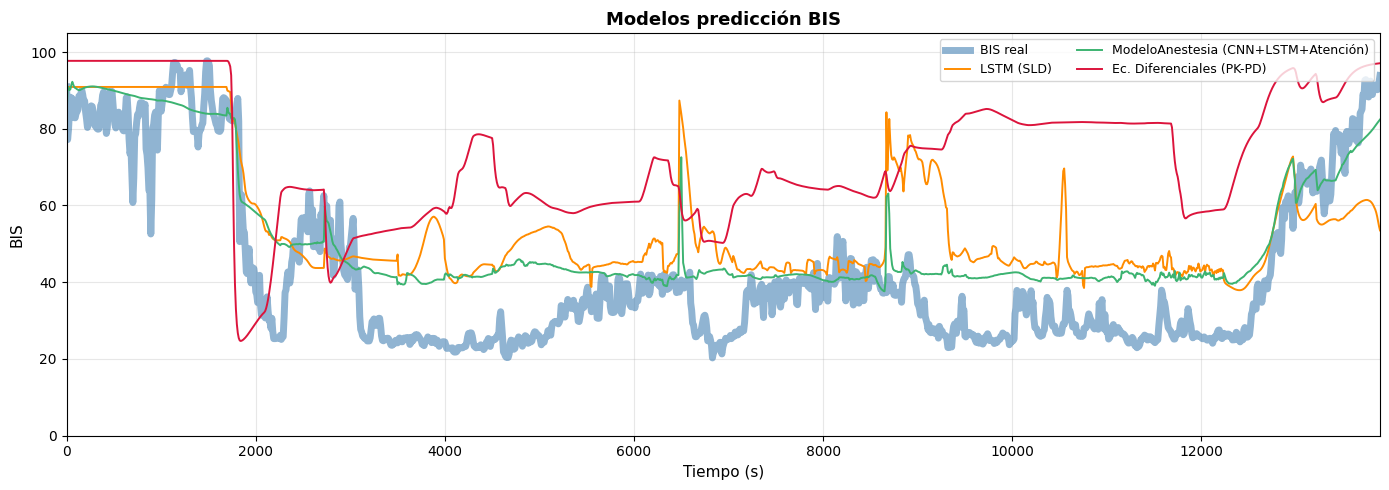

In [22]:
# =============================================================================
# GRÁFICA COMPARATIVA 
# =============================================================================

if not os.path.isfile(RUTA_CSV_GRAFICA):
    raise FileNotFoundError(f"No existe el archivo de gráfica: {RUTA_CSV_GRAFICA}")

print(f"Graficando: {os.path.basename(RUTA_CSV_GRAFICA)}")
res = predecir_archivo(RUTA_CSV_GRAFICA)

tiempo         = res["tiempo"]
bis_gt         = res["bis_gt"]
pred_lstm      = res["pred_lstm"]
pred_anestesia = res["pred_anestesia"]
pred_ecdif     = res["pred_ecdif"]

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(tiempo, bis_gt, color="steelblue", linewidth=5.0, alpha=0.6,
        label="BIS real")
ax.plot(tiempo, pred_lstm, color="darkorange", linewidth=1.4,
        label="LSTM (SLD)")
ax.plot(tiempo, pred_anestesia, color="mediumseagreen", linewidth=1.4,
        label="ModeloAnestesia (CNN+LSTM+Atención)")
ax.plot(tiempo, pred_ecdif, color="crimson", linewidth=1.4,
        label="Ec. Diferenciales (PK-PD)")


ax.set_xlabel("Tiempo (s)", fontsize=11)
ax.set_ylabel("BIS", fontsize=11)
ax.set_title(f"Modelos predicción BIS",
             fontsize=13, fontweight="bold")
ax.set_ylim(0, 105)
ax.set_xlim(tiempo[0], tiempo[-1])
ax.legend(loc="upper right", fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [10]:
# =============================================================================
# MÉTRICAS SOBRE TODOS LOS CSV DE LA CARPETA
# =============================================================================
# Para cada archivo CSV se calculan las métricas MAE, MSE, RMSE y MAPE
# correspondientes a cada modelo. Posteriormente, dichas métricas se agregan
# entre archivos mediante su media y su desviación estándar, con el objeto de
# reportar el resultado en la forma media ± desviación estándar para cada
# modelo y cada métrica.
# =============================================================================

def calcular_metricas(y_real, y_pred):
    """
    Calcula las métricas MAE, MSE, RMSE y MAPE entre el valor real y el
    valor predicho. Se excluyen del cálculo los pares con valores no
    finitos y, en el caso particular del MAPE, aquellos en los que el
    valor real de BIS es menor o igual a EPS_MAPE, con el fin de evitar
    divisiones por un valor cercano a cero.
    """
    m = np.isfinite(y_real) & np.isfinite(y_pred)
    yr, yp = y_real[m], y_pred[m]
    err = yp - yr
    mae  = np.mean(np.abs(err))
    mse  = np.mean(err ** 2)
    rmse = np.sqrt(mse)
    mm   = m & (np.abs(y_real) > EPS_MAPE)   # evita dividir por BIS ~ 0
    mape = np.mean(np.abs((y_real[mm] - y_pred[mm]) / y_real[mm])) * 100.0
    return mae, mse, rmse, mape


archivos_csv = sorted(glob.glob(os.path.join(CARPETA_CSV, "*.csv")))
if not archivos_csv:
    raise FileNotFoundError(f"No se encontraron CSV en: {CARPETA_CSV}")

print(f"Procesando {len(archivos_csv)} archivos...\n")

MODELOS = ["LSTM (SLD)", "ModeloAnestesia", "Ec. Diferenciales"]
METRICAS = ["MAE", "MSE", "RMSE", "MAPE"]
filas_detalle = []

for ruta in archivos_csv:
    try:
        r = predecir_archivo(ruta)
    except Exception as e:
        print(f"  [SALTADO] {os.path.basename(ruta)} -> {e}")
        continue

    preds = {
        "LSTM (SLD)":        r["pred_lstm"],
        "ModeloAnestesia":   r["pred_anestesia"],
        "Ec. Diferenciales": r["pred_ecdif"],
    }
    for nombre_modelo, pred in preds.items():
        mae, mse, rmse, mape = calcular_metricas(r["bis_gt"], pred)
        filas_detalle.append({
            "Archivo": r["nombre"], "Modelo": nombre_modelo,
            "MAE": mae, "MSE": mse, "RMSE": rmse, "MAPE": mape,
        })
    print(f"  OK  {r['nombre']}")

detalle = pd.DataFrame(filas_detalle)

# ── Agregación entre archivos: media y desviación estándar, por modelo ───────
# La desviación estándar se calcula con ddof=1 (estimador insesgado), a fin
# de cuantificar la dispersión de cada métrica entre los distintos pacientes.
media_metricas = (detalle
                   .groupby("Modelo")[METRICAS]
                   .mean()
                   .reindex(MODELOS))
desv_metricas = (detalle
                  .groupby("Modelo")[METRICAS]
                  .std(ddof=1)
                  .reindex(MODELOS))

resumen = media_metricas.round(3)
resumen["MAPE"] = resumen["MAPE"].round(2)

desviacion = desv_metricas.round(3)
desviacion["MAPE"] = desviacion["MAPE"].round(2)

# ── Tabla combinada en el formato "media ± desviación estándar" ──────────────
resumen_formato = pd.DataFrame(index=MODELOS)
for metrica in METRICAS:
    decimales = 2 if metrica == "MAPE" else 3
    resumen_formato[metrica] = (
        resumen[metrica].map(lambda v, d=decimales: f"{v:.{d}f}")
        + " ± "
        + desviacion[metrica].map(lambda v, d=decimales: f"{v:.{d}f}")
    )

print("\n" + "=" * 70)
print("TABLA RESUMEN — media de cada métrica entre todos los CSV")
print("=" * 70)
print(resumen.to_string())

print("\n" + "=" * 70)
print("TABLA RESUMEN — desviación estándar de cada métrica entre todos los CSV")
print("=" * 70)
print(desviacion.to_string())

print("\n" + "=" * 70)
print("TABLA RESUMEN — media ± desviación estándar, por modelo y métrica")
print("=" * 70)
print(resumen_formato.to_string())

try:
    from IPython.display import display
    display(resumen_formato)
except Exception:
    pass


Procesando 32 archivos...

  OK  Paciente_1032_limpio_SinFiltro.csv
  OK  Paciente_1140_limpio_SinFiltro.csv
  OK  Paciente_1239_limpio_SinFiltro.csv
  OK  Paciente_1251_limpio_SinFiltro.csv
  OK  Paciente_2124_limpio_SinFiltro.csv
  OK  Paciente_2144_limpio_SinFiltro.csv
  OK  Paciente_2453_limpio_SinFiltro.csv
  OK  Paciente_2540_limpio_SinFiltro.csv
  OK  Paciente_2733_limpio_SinFiltro.csv
  OK  Paciente_3298_limpio_SinFiltro.csv
  OK  Paciente_3840_limpio_SinFiltro.csv
  OK  Paciente_4283_limpio_SinFiltro.csv
  OK  Paciente_4822_limpio_SinFiltro.csv
  OK  Paciente_482_limpio_SinFiltro.csv
  OK  Paciente_4929_limpio_SinFiltro.csv
  OK  Paciente_4960_limpio_SinFiltro.csv
  OK  Paciente_4994_limpio_SinFiltro.csv
  OK  Paciente_5251_limpio_SinFiltro.csv
  OK  Paciente_5278_limpio_SinFiltro.csv
  OK  Paciente_5508_limpio_SinFiltro.csv
  OK  Paciente_5603_limpio_SinFiltro.csv
  OK  Paciente_5690_limpio_SinFiltro.csv
  OK  Paciente_5874_limpio_SinFiltro.csv
  OK  Paciente_590_limpio_SinFi

,MAE,MSE,RMSE,MAPE
LSTM (SLD),9.468 ± 3.354,150.189 ± 96.960,11.747 ± 3.547,24.40 ± 13.95
ModeloAnestesia,8.235 ± 2.551,115.573 ± 59.819,10.405 ± 2.748,20.45 ± 9.48
Ec. Diferenciales,18.693 ± 10.261,567.597 ± 711.563,21.796 ± 9.774,47.39 ± 37.93


In [ ]:
# =============================================================================
# DETALLE POR ARCHIVO 
# =============================================================================

detalle_fmt = detalle.copy()
for c in ["MAE", "MSE", "RMSE"]:
    detalle_fmt[c] = detalle_fmt[c].round(3)
detalle_fmt["MAPE"] = detalle_fmt["MAPE"].round(2)

# Tabla pivote por métrica para comparar modelos lado a lado
for metrica in ["MAE", "MSE", "RMSE", "MAPE"]:
    print(f"\n=== {metrica} por archivo ===")
    piv = detalle.pivot(index="Archivo", columns="Modelo", values=metrica)
    piv = piv.reindex(columns=MODELOS).round(3 if metrica != "MAPE" else 2)
    print(piv.to_string())

try:
    from IPython.display import display
    display(detalle_fmt)
except Exception:
    pass



=== MAE por archivo ===
Modelo                              LSTM (SLD)  ModeloAnestesia  Ec. Diferenciales
Archivo                                                                           
Paciente_1032_limpio_SinFiltro.csv      12.732           11.738          19.480000
Paciente_1140_limpio_SinFiltro.csv      12.833           10.891          14.674000
Paciente_1239_limpio_SinFiltro.csv       8.647           11.394          12.337000
Paciente_1251_limpio_SinFiltro.csv       6.742            6.031          21.586000
Paciente_2124_limpio_SinFiltro.csv       7.769            9.592           8.486000
Paciente_2144_limpio_SinFiltro.csv      13.922           13.307          18.525999
Paciente_2453_limpio_SinFiltro.csv       6.001            6.232          16.233000
Paciente_2540_limpio_SinFiltro.csv       7.048            7.790          13.678000
Paciente_2733_limpio_SinFiltro.csv       9.579            8.328          25.822001
Paciente_3298_limpio_SinFiltro.csv      17.910           12.69

,Archivo,Modelo,MAE,MSE,RMSE,MAPE
0,Paciente_1032_limpio_SinFiltro.csv,LSTM (SLD),12.732000,208.207001,14.429000,20.790001
1,Paciente_1032_limpio_SinFiltro.csv,ModeloAnestesia,11.738000,179.526993,13.399000,20.500000
2,Paciente_1032_limpio_SinFiltro.csv,Ec. Diferenciales,19.480000,448.321991,21.174000,34.180000
3,Paciente_1140_limpio_SinFiltro.csv,LSTM (SLD),12.833000,228.593994,15.119000,41.419998
4,Paciente_1140_limpio_SinFiltro.csv,ModeloAnestesia,10.891000,163.916000,12.803000,33.360001
...,...,...,...,...,...,...
91,Paciente_831_limpio_SinFiltro.csv,ModeloAnestesia,3.603000,24.507000,4.950000,8.020000
92,Paciente_831_limpio_SinFiltro.csv,Ec. Diferenciales,16.532000,367.312012,19.165001,38.889999
93,Paciente_985_limpio_SinFiltro.csv,LSTM (SLD),7.582000,119.529999,10.933000,20.580000
94,Paciente_985_limpio_SinFiltro.csv,ModeloAnestesia,5.817000,71.294998,8.444000,15.960000
